# OpenSim Pendulum: Basics

In this tutorial, we build a simple rigid-body pendulum model using [OpenSim](https://opensim.stanford.edu/) and its Python API.

1. **Basics** (this tutorial): We set up a single-link pendulum with a pin joint and simulate its free swing under gravity.
2. **[Torque Application](02_opensim_pendulum_torque.ipynb)**: We extend the model by applying an external torque via a `CoordinateActuator`.
3. **[Contact Handling](03_opensim_pendulum_contact.ipynb)**: We further extend the model by adding contact geometry and forces.

```{figure} pendulum_1.png
---
width: 60%
figclass: caption
alt: opensim-pendulum-fig-basic
name: opensim-pendulum-fig-basic
---
Pendulum model in the OpenSim visualizer.
```

## Overview
We construct a planar pendulum from scratch using OpenSim's building blocks:
1. **Bodies** – rigid segments with mass and inertia properties,
2. **Joints** – kinematic connections that define how bodies move relative to each other,
3. **Geometry** – visual shapes attached to bodies for visualization,
4. **Coordinates** – generalized coordinates that parameterize the joint motion,
5. **Manager** – the simulation driver that integrates the equations of motion.

This notebook focuses on the core model construction and free-swing dynamics before adding torque actuation or contact forces.

## Learning Goals
- Understand the OpenSim model hierarchy: `Model → Bodies → Joints → Coordinates`
- Create rigid bodies with mass properties and visualization geometry
- Connect bodies using `WeldJoint` (fixed) and `PinJoint` (1-DOF rotation)
- Set initial conditions via coordinate default values
- Run a forward dynamics simulation using the `Manager`
- Extract and plot time-series results (angle, velocity, acceleration)
- Perform a parameter study to compare pendulum configurations

## Prerequisites and Setup
- You have installed [OpenSim](https://opensim.stanford.edu/) (version 4.x+) and its Python bindings (`opensim` package)
- You have `numpy` and `matplotlib` available
- You are comfortable running Jupyter Notebook cells

**Background:** OpenSim solves the equations of motion using the [Simbody](https://simtk.org/projects/simbody) multibody dynamics engine. For a single-link pendulum with generalized coordinate $\theta$ (the joint angle), the equation of motion is:

$$I\,\ddot{\theta} = -m\,g\,L\,\sin(\theta) + \tau$$

where $I$ is the moment of inertia about the pivot, $m$ is the mass, $L$ is the distance from the pivot to the center of mass, and $\tau$ is any applied torque. OpenSim assembles and integrates this equation (and its multi-body generalizations) automatically from the model description.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import opensim as osim

## Physical Model

Our pendulum consists of two bodies:

| Body | Role | Joint to parent |
|------|------|-----------------|
| **Base** | Fixed pivot point attached to ground | `WeldJoint` (0 DOF) |
| **Head** | Swinging mass at the end of a rod | `PinJoint` (1 DOF, rotation about $z$-axis) |

The `PinJoint` introduces a single generalized coordinate $\theta$ that measures the rotation of the pendulum relative to the vertical. OpenSim's convention places the rotation axis along the $z$-axis of the joint frames.

### Coordinate Frames and Joint Offsets

Each joint connects a **parent frame** to a **child frame**. The frames can be offset from the body origins:

- The parent frame offset positions the joint relative to the parent body.
- The child frame offset positions the joint relative to the child body.

For our pendulum, the child (head) frame is offset by the rod length $L$ along the $y$-axis, so the head's center of mass hangs at distance $L$ below the pivot.

## Model Parameters
We define the physical parameters of the pendulum. All quantities are in SI units.

In [2]:
mass = 1.0         # mass of the pendulum head [kg]
r_head = 0.025     # radius of the pendulum head (visualization) [m]
length = 0.4       # length of the pendulum rod [m]
inertia_head = 0.1 # moment of inertia of the head about Z-axis [kg·m²]
g_val = 9.81       # gravitational acceleration [m/s²]

## Building the OpenSim Model

We now construct the model step by step. The general workflow is:
1. Create a `Model` and set gravity.
2. Add bodies with mass, inertia, and geometry.
3. Connect bodies with joints.
4. Set default coordinate values (initial conditions).
5. Finalize connections.

### Instantiate the Model and Set Gravity

Every OpenSim model starts with a `Model` object. We set gravity to point in the negative $y$-direction, which is the standard convention.

In [3]:
model = osim.Model()
model.setName('Pendulum')
model.setGravity(osim.Vec3(0, -g_val, 0))

True

### Ground Frame

The `Ground` body is the immovable reference frame of the model. All other bodies are connected (directly or indirectly) to the ground through joints.

In [4]:
ground = model.getGround()

### Add the Base Body (Fixed Pivot)

The base body acts as the fixed pivot point of the pendulum. It is attached to the ground via a `WeldJoint`, which means it has **zero degrees of freedom** — it cannot move relative to the ground.

We position the base above the ground origin so the pendulum has room to swing.

> **Note:** The base body needs a mass, but since it is welded to the ground, its mass does not affect the simulation.

In [5]:
base_name = "pendulum_base"
base_mass = 1.0
base_com = osim.Vec3(0, 0, 0)
base_inertia = osim.Inertia(0, 0, 0)
base = osim.Body(base_name, base_mass, base_com, base_inertia)

# Visualization: a flat brick representing the pivot support
base_geom = osim.Brick(osim.Vec3(0.1, 0.01, 0.1))
base_geom.setColor(osim.Vec3(0.8, 0.2, 0.2))
base.attachGeometry(base_geom)
model.addBody(base)

### Weld the Base to Ground

A `WeldJoint` fixes the base body at a specified position relative to the ground. We place it at a height of $1.2 \times L$ so the pendulum can swing freely below.

In [6]:
ground_translation = osim.Vec3(0, 1.2 * length, 0)
ground_orientation = osim.Vec3(0, 0, 0)
base_translation = osim.Vec3(0, 0, 0)
base_orientation = osim.Vec3(0, 0, 0)

base_to_ground = osim.WeldJoint(
    "base_to_ground",
    ground,              # parent body
    ground_translation,  # position in parent frame
    ground_orientation,  # orientation in parent frame
    base,                # child body
    base_translation,    # position in child frame
    base_orientation,    # orientation in child frame
)
model.addJoint(base_to_ground)

### Add the Pendulum Head Body

The pendulum head is the swinging mass. We define its mass, center of mass (at the body origin), and moment of inertia about the $z$-axis (the rotation axis).

The `Inertia` constructor takes $(I_{xx}, I_{yy}, I_{zz})$ for the diagonal elements. Since the pendulum rotates about the $z$-axis, $I_{zz}$ is the relevant inertia component.

In [7]:
head_name = "pendulum_head"
head_com = osim.Vec3(0, 0, 0)
head_inertia = osim.Inertia(0, 0, inertia_head)
head = osim.Body(head_name, mass, head_com, head_inertia)

# Visualization: a sphere representing the pendulum bob
head_geom = osim.Sphere(r_head)
head_geom.setColor(osim.Vec3(0.2, 0.2, 0.8))
head.attachGeometry(head_geom)
model.addBody(head)

### Connect With a Pin Joint

A `PinJoint` provides a single rotational degree of freedom about the $z$-axis of the joint frames. This is the natural choice for a planar pendulum.

**Frame offsets:**
- The **parent frame** (base) is at the base body's origin — this is the pivot location.
- The **child frame** (head) is offset by `(0, L, 0)` — meaning the head's origin is at distance $L$ *below* the joint. In OpenSim the child frame offset defines where the joint sits relative to the child body.

In [8]:
base_translation = osim.Vec3(0, 0, 0)
base_orientation = osim.Vec3(0, 0, 0)
head_translation = osim.Vec3(0, length, 0)
head_orientation = osim.Vec3(0, 0, 0)

head_to_base = osim.PinJoint(
    "head_to_base",
    base,              # parent body
    base_translation,  # position in parent frame
    base_orientation,  # orientation in parent frame
    head,              # child body
    head_translation,  # position in child frame
    head_orientation,  # orientation in child frame
)
model.addJoint(head_to_base)

### Add Rod Visualization

To visualize the rod connecting the pivot to the head, we attach a `Cylinder` geometry to a `PhysicalOffsetFrame`. This frame is fixed to the head body but offset to the midpoint of the rod.

In [9]:
head_of = osim.PhysicalOffsetFrame()
head_of.setName("head_of")
head_of.setParentFrame(head)
head_of.set_translation(osim.Vec3(0, length / 2, 0))

head_of_geom = osim.Cylinder(0.01, length / 2)
head_of_geom.setColor(osim.Vec3(0.2, 0.8, 0.2))
head_of.attachGeometry(head_of_geom)
head.addComponent(head_of)

### Set Initial Conditions

We set the default value of the pendulum coordinate $\theta$ (angle) and its speed $\dot{\theta}$ (angular velocity). These serve as the initial conditions for the simulation.

- `setDefaultValue(q0)` — initial angular position
- `setDefaultSpeedValue(omega0)` — initial angular velocity

In [10]:
q0 = np.deg2rad(45)  # initial angle [rad]
omega0 = 0.0         # initial angular velocity [rad/s]

coord = head_to_base.getCoordinate()
coord.setName("theta")
coord.setDefaultValue(q0)
coord.setDefaultSpeedValue(omega0)

### Finalize and Visualize

Calling `finalizeConnections()` resolves all internal references between components. The model is then ready for simulation.

In [12]:
model.finalizeConnections()
visualizer = osim.VisualizerUtilities()
visualizer.showModel(model)

The visualizer window shows the pendulum in its initial configuration with $\theta_0 = 45°$. The red brick is the fixed base, the green cylinder is the rod, and the blue sphere is the swinging mass.

### Create `.osim` Model File

To save the model for later use or to open it in the OpenSim GUI, we write it to an `.osim` file. This XML file contains the full model description and can be loaded by OpenSim tools.

In [13]:
model.printToXML("pendulum_baiscs.osim")

True

## Initialize the System

Before simulation, we initialize the system state. OpenSim uses Simbody's **realization** stages to compute derived quantities (positions, velocities, forces, accelerations) on demand.

- `initSystem()` creates an initial `State` object consistent with the model.
- `realizeAcceleration(state)` computes all quantities up to (and including) accelerations, ensuring the state is fully consistent before the simulation starts.
- The `Manager` wraps the numerical integrator (a 5th-order Runge-Kutta-Feldberg method by default) and advances the state through time.

In [14]:
state = model.initSystem()
model.realizeAcceleration(state)

manager = osim.Manager(model)
manager.initialize(state)

## Simulate the Free-Swinging Pendulum

We integrate the equations of motion from $t=0$ to $t_\mathrm{end}$ with a reporting interval of `dt`. At each reporting step, we extract the coordinate value $\theta$, speed $\dot\theta$, and acceleration $\ddot\theta$.

> **Note:** The `Manager.integrate(t)` call advances the internal state to time $t$. The integrator uses adaptive step sizes internally; `dt` here controls how often we *sample* the solution, not the integration step size.

In [15]:
t = 0.0
dt = 0.001
t_end = 5.0

t_vals = []
theta_vals = []
omega_vals = []
alpha_vals = []

while t < t_end - 1e-8:
    state = manager.integrate(t + dt)

    theta = coord.getValue(state)
    omega = coord.getSpeedValue(state)
    model.realizeAcceleration(state)
    alpha = coord.getAccelerationValue(state)

    t_vals.append(state.getTime())
    theta_vals.append(theta)
    omega_vals.append(omega)
    alpha_vals.append(alpha)

    t = state.getTime()

### Plot the Results

We plot the angular position $\theta$, angular velocity $\dot\theta$, and angular acceleration $\ddot\theta$ as functions of time.

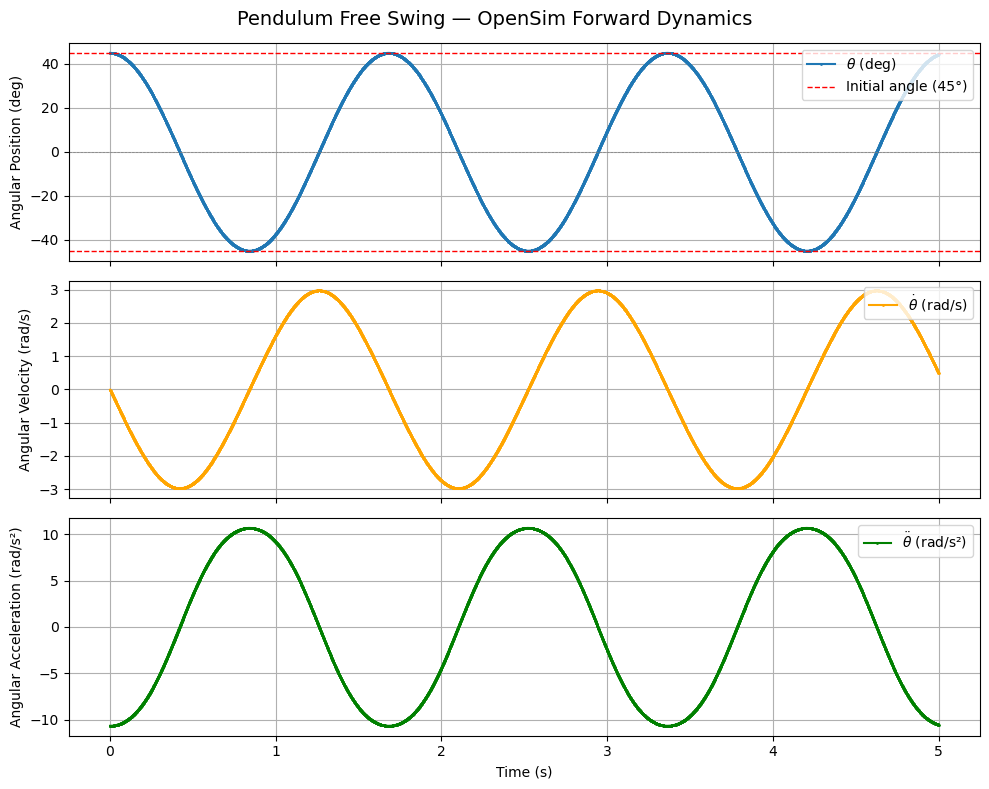

In [16]:
style = {'marker': 'o', 'markersize': 1, 'linestyle': '-'}

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t_vals, np.rad2deg(theta_vals), label=r'$\theta$ (deg)', **style)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[0].axhline(np.rad2deg(q0), color='red', linestyle='--', linewidth=1, label=f'Initial angle ({np.rad2deg(q0):.0f}°)')
axes[0].axhline(-np.rad2deg(q0), color='red', linestyle='--', linewidth=1)
axes[0].set_ylabel('Angular Position (deg)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

axes[1].plot(t_vals, omega_vals, label=r'$\dot\theta$ (rad/s)', color='orange', **style)
axes[1].set_ylabel('Angular Velocity (rad/s)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

axes[2].plot(t_vals, alpha_vals, label=r'$\ddot\theta$ (rad/s²)', color='green', **style)
axes[2].set_ylabel('Angular Acceleration (rad/s²)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(loc='upper right')
axes[2].grid(True)

fig.suptitle('Pendulum Free Swing — OpenSim Forward Dynamics', fontsize=14)
plt.tight_layout()
plt.show()

The pendulum oscillates symmetrically about the vertical ($\theta=0$). Since there is no damping, the amplitude remains constant. The angular velocity is zero at the turning points and maximal at the bottom, while the acceleration is proportional to $-\sin(\theta)$.

### Visualize the Motion

We can replay the simulation in the OpenSim visualizer using the stored states table.

In [18]:
states_table = manager.getStatesTable()
statesTraj = osim.StatesTrajectory.createFromStatesTable(model, states_table)
visualizer.showMotion(model, states_table)

## Conclusion

In this tutorial we:
- Built an OpenSim pendulum model using the `Body`, `WeldJoint`, and `PinJoint` classes.
- Set initial conditions via the coordinate default values.
- Ran a forward dynamics simulation using the `Manager` and extracted time-series outputs.
- Compared different parameter configurations in a parameter study.

This model serves as the foundation for the next tutorials, where we add torque actuation and contact handling to the pendulum.